# Experiment 4: Industry Effects on Salary and Skill Requirements

**Hypothesis:**  
*Job postings in technology and finance industries will exhibit higher average salaries and more advanced skill requirements than other sectors.*

This notebook follows the same workflow style as Experiment 2, reuses functions from `helpers.py`, and tests the hypothesis using:
1. **Salary comparison** across industry groups  
2. **Advanced-skill requirement comparison** across industry groups  
3. **A final support / mixed / reject conclusion**


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind

from helpers import SKILL_PATTERNS, extract_skill_lists, parse_salary
from job_dataset_union import UNIFIED_REQUIRED_COLUMNS, build_unified_jobs_df

SALARY_COLUMN = "salary_range"
JOB_TEXT_COLUMN = "job_description_skills"
INDUSTRY_COLUMN = "industry"
INDUSTRY_PLACEHOLDERS = {"", "-1", "Unknown"}

ADVANCED_SKILLS = [
    "Machine Learning", "Deep Learning", "NLP", "Computer Vision", "Generative AI",
    "Reinforcement Learning", "Scikit-learn", "TensorFlow", "PyTorch", "XGBoost",
    "LightGBM", "Spark", "Databricks", "AWS", "Azure", "GCP", "Docker",
    "Kubernetes", "Airflow", "dbt", "Snowflake", "BigQuery", "Model Deployment",
    "Feature Engineering", "Data Warehousing",
]

TECH_PATTERN = re.compile(
    r"software|information technology|it services|internet|computer|semiconductor|"
    r"electronics|cyber|cloud|saas|data platform|telecommunications|tech",
    flags=re.IGNORECASE,
)

FINANCE_PATTERN = re.compile(
    r"financial|bank|banking|investment|capital markets|asset management|insurance|"
    r"fintech|payments|trading|wealth management|credit|lending|private equity|hedge fund",
    flags=re.IGNORECASE,
)


In [2]:
df = build_unified_jobs_df().copy()

missing_columns = [col for col in UNIFIED_REQUIRED_COLUMNS if col not in df.columns]
if missing_columns:
    raise ValueError(f"Unified dataset is missing required columns: {missing_columns}")

print(f"Loaded {len(df)} postings from the unified dataset.")
print("Using exact unified columns for this experiment:")
print({
    "salary": SALARY_COLUMN,
    "job_text": JOB_TEXT_COLUMN,
    "industry": INDUSTRY_COLUMN,
})

print("\nUnified dataset columns:")
print(df.columns.tolist())


Loaded 4444 postings from the unified dataset.
Using exact unified columns for this experiment:
{'salary': 'salary_range', 'job_text': 'job_description_skills', 'industry': 'industry'}

Unified dataset columns:
['job_title', 'location', 'sector', 'salary_range', 'industry', 'job_description_skills', 'source_dataset', 'Rating', 'Company Name', 'Size', 'Founded', 'Type of ownership', 'Revenue', 'seniority_level', 'status', 'company', 'post_date', 'headquarter', 'ownership', 'company_size', 'revenue', 'workType', 'link', 'source']


In [3]:
analysis_df = df.copy()
analysis_df["Salary_Numeric"] = analysis_df[SALARY_COLUMN].apply(parse_salary)
analysis_df["job_text"] = analysis_df[JOB_TEXT_COLUMN].fillna("").astype(str)
analysis_df["industry_text"] = analysis_df[INDUSTRY_COLUMN].fillna("").astype(str).str.strip()

salary_valid_count = analysis_df["Salary_Numeric"].notna().sum()
analysis_df = analysis_df[analysis_df["Salary_Numeric"].notna()].copy()

placeholder_mask = analysis_df["industry_text"].isin(INDUSTRY_PLACEHOLDERS)
excluded_placeholder_count = int(placeholder_mask.sum())
analysis_df = analysis_df[~placeholder_mask].copy()

print(f"Rows with valid salary data: {salary_valid_count} / {len(df)}")
print(f"Rows excluded from industry analysis because industry is missing or placeholder: {excluded_placeholder_count}")
print(f"Rows used in Experiment 4: {len(analysis_df)}")

print("\nSalary summary (USD):")
print(analysis_df["Salary_Numeric"].describe())


Rows with valid salary data: 2361 / 4444
Rows excluded from industry analysis because industry is missing or placeholder: 463
Rows used in Experiment 4: 1898

Salary summary (USD):
count    1.898000e+03
mean     1.373011e+05
std      1.014956e+05
min      2.035575e+04
25%      1.010000e+05
50%      1.264983e+05
75%      1.685375e+05
max      2.986577e+06
Name: Salary_Numeric, dtype: float64


In [4]:
def classify_industry_group(industry_name: str) -> str:
    if TECH_PATTERN.search(industry_name):
        return "Technology"
    if FINANCE_PATTERN.search(industry_name):
        return "Finance"
    return "Other"

analysis_df["Industry_Group"] = analysis_df["industry_text"].apply(classify_industry_group)

print("Industry-group counts:")
print(analysis_df["Industry_Group"].value_counts())

print("\nTop raw industry values used in the analysis:")
print(analysis_df["industry_text"].value_counts().head(20))


Industry-group counts:
Industry_Group
Technology    961
Other         796
Finance       141
Name: count, dtype: int64

Top raw industry values used in the analysis:
industry_text
Technology                                 582
Information Technology Support Services    130
Finance                                    127
Retail                                     110
Healthcare                                  83
Aerospace & Defense                         67
Enterprise Software & Network Solutions     65
Computer Hardware Development               63
Insurance Carriers                          56
Internet & Web Services                     51
Health Care Services & Hospitals            49
Research & Development                      35
Biotech & Pharmaceuticals                   34
Banking & Lending                           33
Colleges & Universities                     31
Investment & Asset Management               28
Advertising & Public Relations              26
Publishing            

In [5]:
analysis_df["skill_list"] = extract_skill_lists(analysis_df["job_text"], SKILL_PATTERNS)
analysis_df["advanced_skill_count"] = analysis_df["skill_list"].apply(
    lambda skills: sum(skill in ADVANCED_SKILLS for skill in skills)
)
analysis_df["has_advanced_skill"] = analysis_df["advanced_skill_count"] > 0

print(analysis_df[["Industry_Group", "advanced_skill_count", "Salary_Numeric"]].head())


  Industry_Group  advanced_skill_count  Salary_Numeric
1     Technology                     2        118000.0
2     Technology                     1        102000.0
3     Technology                     1        138500.0
4          Other                     0         63000.0
6     Technology                     0        197500.0


In [6]:
group_summary = (
    analysis_df.groupby("Industry_Group")
    .agg(
        Postings=("Industry_Group", "size"),
        Avg_Salary=("Salary_Numeric", "mean"),
        Median_Salary=("Salary_Numeric", "median"),
        Avg_Advanced_Skills=("advanced_skill_count", "mean"),
        Median_Advanced_Skills=("advanced_skill_count", "median"),
        Share_With_Advanced_Skills=("has_advanced_skill", "mean"),
    )
    .reset_index()
)

group_summary["Avg_Salary_K"] = group_summary["Avg_Salary"] / 1000
group_summary["Median_Salary_K"] = group_summary["Median_Salary"] / 1000
group_summary["Share_With_Advanced_Skills"] = group_summary["Share_With_Advanced_Skills"] * 100

group_summary = group_summary[
    [
        "Industry_Group", "Postings", "Avg_Salary_K", "Median_Salary_K",
        "Avg_Advanced_Skills", "Median_Advanced_Skills", "Share_With_Advanced_Skills",
    ]
].sort_values("Avg_Salary_K", ascending=False)

print("Industry comparison summary:")
print(group_summary.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))


Industry comparison summary:
Industry_Group  Postings  Avg_Salary_K  Median_Salary_K  Avg_Advanced_Skills  Median_Advanced_Skills  Share_With_Advanced_Skills
    Technology       961        144.10           131.43                 1.35                    1.00                       50.99
         Other       796        131.86           125.00                 1.26                    0.00                       47.86
       Finance       141        121.73           112.50                 0.38                    0.00                       28.37


In [7]:
target = analysis_df[analysis_df["Industry_Group"].isin(["Technology", "Finance"])].copy()
other = analysis_df[analysis_df["Industry_Group"] == "Other"].copy()

salary_t = ttest_ind(target["Salary_Numeric"], other["Salary_Numeric"], equal_var=False, nan_policy="omit")
skill_t = ttest_ind(target["advanced_skill_count"], other["advanced_skill_count"], equal_var=False, nan_policy="omit")

salary_u = mannwhitneyu(target["Salary_Numeric"], other["Salary_Numeric"], alternative="two-sided")
skill_u = mannwhitneyu(target["advanced_skill_count"], other["advanced_skill_count"], alternative="two-sided")

print(f"Technology + Finance postings: {len(target)}")
print(f"Other postings: {len(other)}")
print("\nWelch t-test for salary:")
print(salary_t)
print("\nWelch t-test for advanced skill count:")
print(skill_t)
print("\nMann-Whitney U test for salary:")
print(salary_u)
print("\nMann-Whitney U test for advanced skill count:")
print(skill_u)


Technology + Finance postings: 1102
Other postings: 796

Welch t-test for salary:
TtestResult(statistic=np.float64(2.2388611251126647), pvalue=np.float64(0.025308782017962085), df=np.float64(1524.0872636952354))

Welch t-test for advanced skill count:
TtestResult(statistic=np.float64(-0.39105584566349694), pvalue=np.float64(0.6958031884133385), df=np.float64(1763.7917414453764))

Mann-Whitney U test for salary:
MannwhitneyuResult(statistic=np.float64(460944.5), pvalue=np.float64(0.0578505265389974))

Mann-Whitney U test for advanced skill count:
MannwhitneyuResult(statistic=np.float64(431499.0), pvalue=np.float64(0.5131726791841958))


In [8]:
comparison_rows = []

for label in ["Technology", "Finance"]:
    subset = analysis_df[analysis_df["Industry_Group"] == label]
    salary_test = ttest_ind(subset["Salary_Numeric"], other["Salary_Numeric"], equal_var=False, nan_policy="omit")
    skill_test = ttest_ind(subset["advanced_skill_count"], other["advanced_skill_count"], equal_var=False, nan_policy="omit")

    comparison_rows.append({
        "Group": label,
        "N": len(subset),
        "Avg Salary ($K)": subset["Salary_Numeric"].mean() / 1000,
        "Other Avg Salary ($K)": other["Salary_Numeric"].mean() / 1000,
        "Salary p-value": salary_test.pvalue,
        "Avg Advanced Skills": subset["advanced_skill_count"].mean(),
        "Other Avg Advanced Skills": other["advanced_skill_count"].mean(),
        "Advanced Skills p-value": skill_test.pvalue,
    })

comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))


     Group   N  Avg Salary ($K)  Other Avg Salary ($K)  Salary p-value  Avg Advanced Skills  Other Avg Advanced Skills  Advanced Skills p-value
Technology 961         144.0964               131.8560          0.0090               1.3476                     1.2575                   0.3311
   Finance 141         121.7270               131.8560          0.0007               0.3759                     1.2575                   0.0000


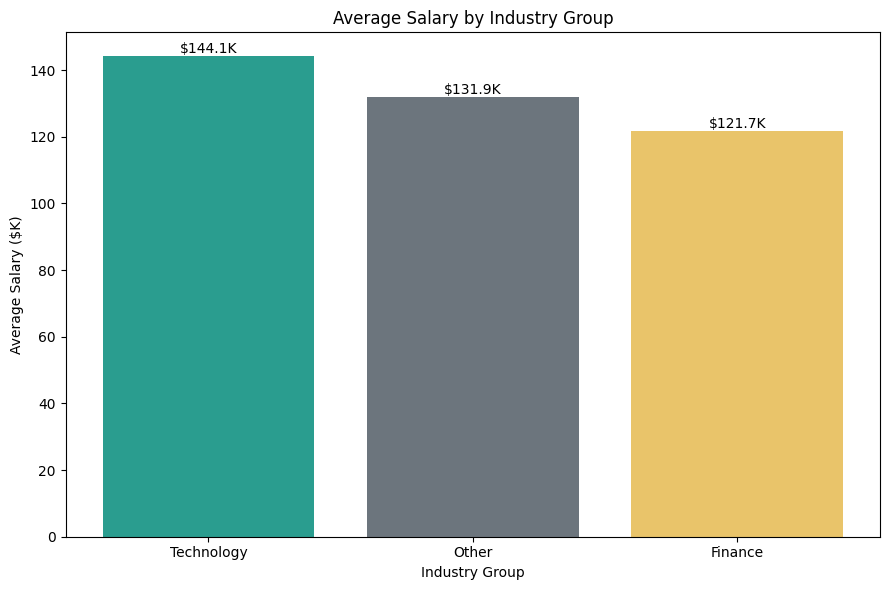

In [9]:
salary_plot_df = group_summary.sort_values("Avg_Salary_K", ascending=False)
colors = {"Technology": "#2a9d8f", "Finance": "#e9c46a", "Other": "#6c757d"}

plt.figure(figsize=(9, 6))
plt.bar(
    salary_plot_df["Industry_Group"],
    salary_plot_df["Avg_Salary_K"],
    color=[colors[group] for group in salary_plot_df["Industry_Group"]],
)
plt.ylabel("Average Salary ($K)")
plt.xlabel("Industry Group")
plt.title("Average Salary by Industry Group")
for i, value in enumerate(salary_plot_df["Avg_Salary_K"]):
    plt.text(i, value + 1, f"${value:.1f}K", ha="center")
plt.tight_layout()
plt.show()


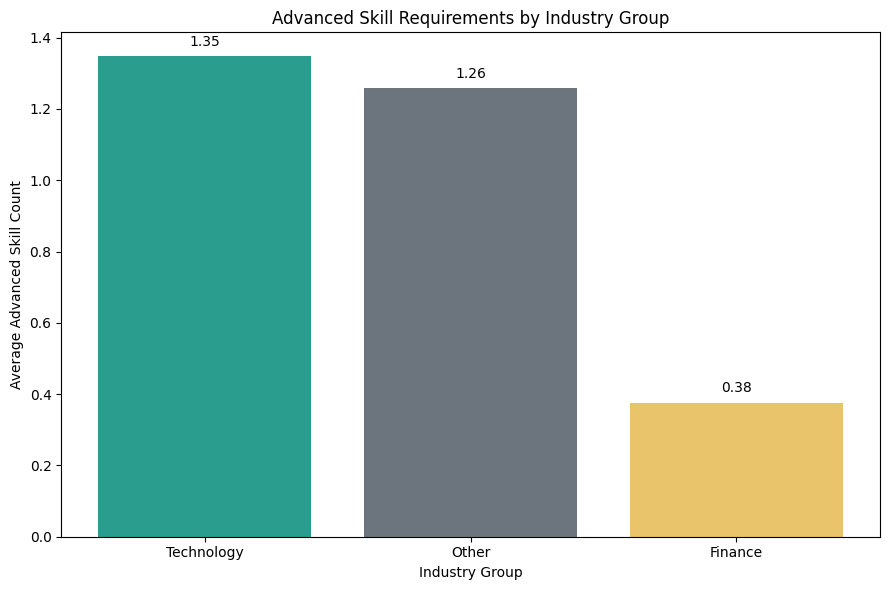

In [10]:
skill_plot_df = group_summary.sort_values("Avg_Advanced_Skills", ascending=False)
colors = {"Technology": "#2a9d8f", "Finance": "#e9c46a", "Other": "#6c757d"}

plt.figure(figsize=(9, 6))
plt.bar(
    skill_plot_df["Industry_Group"],
    skill_plot_df["Avg_Advanced_Skills"],
    color=[colors[group] for group in skill_plot_df["Industry_Group"]],
)
plt.ylabel("Average Advanced Skill Count")
plt.xlabel("Industry Group")
plt.title("Advanced Skill Requirements by Industry Group")
for i, value in enumerate(skill_plot_df["Avg_Advanced_Skills"]):
    plt.text(i, value + 0.03, f"{value:.2f}", ha="center")
plt.tight_layout()
plt.show()


In [11]:
rows = []
for group_name, subset in analysis_df.groupby("Industry_Group"):
    for skill in ADVANCED_SKILLS:
        pct = subset["skill_list"].apply(lambda skills: skill in skills).mean() * 100
        rows.append({
            "Industry_Group": group_name,
            "Skill": skill,
            "Pct_Postings": pct,
        })

industry_skill_df = pd.DataFrame(rows)

for group_name in ["Technology", "Finance", "Other"]:
    print("\n" + "=" * 60)
    print(f"Top advanced skills in {group_name}")
    print("=" * 60)
    top_skills = (
        industry_skill_df[industry_skill_df["Industry_Group"] == group_name]
        .sort_values("Pct_Postings", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    print(top_skills.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))



Top advanced skills in Technology
Industry_Group            Skill  Pct_Postings
    Technology Machine Learning         44.02
    Technology              AWS         13.84
    Technology    Deep Learning         11.65
    Technology            Azure          9.78
    Technology       TensorFlow          9.57
    Technology          PyTorch          9.37
    Technology            Spark          8.32
    Technology              GCP          7.08
    Technology     Scikit-learn          6.45
    Technology           Docker          4.06

Top advanced skills in Finance
Industry_Group            Skill  Pct_Postings
       Finance Machine Learning         25.53
       Finance              NLP          3.55
       Finance            Spark          1.42
       Finance              AWS          1.42
       Finance    Deep Learning          1.42
       Finance Data Warehousing          1.42
       Finance    Generative AI          1.42
       Finance     Scikit-learn          0.71
       Financ

In [12]:
target_avg_salary = target["Salary_Numeric"].mean() / 1000
other_avg_salary = other["Salary_Numeric"].mean() / 1000
target_avg_skills = target["advanced_skill_count"].mean()
other_avg_skills = other["advanced_skill_count"].mean()

technology_row = comparison_df[comparison_df["Group"] == "Technology"].iloc[0]
finance_row = comparison_df[comparison_df["Group"] == "Finance"].iloc[0]

print("=" * 70)
print("EXPERIMENT 4 CONCLUSION")
print("=" * 70)
print(f"Technology + Finance average salary: ${target_avg_salary:.2f}K")
print(f"Other industries average salary:    ${other_avg_salary:.2f}K")
print(f"Technology + Finance avg advanced skills: {target_avg_skills:.2f}")
print(f"Other industries avg advanced skills:     {other_avg_skills:.2f}")
print(f"Combined salary p-value: {salary_t.pvalue:.4g}")
print(f"Combined advanced skills p-value: {skill_t.pvalue:.4g}")

print("\nPer-industry interpretation:")
print(
    f"Technology vs Other: salary {'higher' if technology_row['Avg Salary ($K)'] > technology_row['Other Avg Salary ($K)'] else 'lower'}, "
    f"advanced skills {'higher' if technology_row['Avg Advanced Skills'] > technology_row['Other Avg Advanced Skills'] else 'lower'}"
)
print(
    f"Finance vs Other: salary {'higher' if finance_row['Avg Salary ($K)'] > finance_row['Other Avg Salary ($K)'] else 'lower'}, "
    f"advanced skills {'higher' if finance_row['Avg Advanced Skills'] > finance_row['Other Avg Advanced Skills'] else 'lower'}"
)

if (
    technology_row['Avg Salary ($K)'] > technology_row['Other Avg Salary ($K)']
    and technology_row['Avg Advanced Skills'] > technology_row['Other Avg Advanced Skills']
    and finance_row['Avg Salary ($K)'] > finance_row['Other Avg Salary ($K)']
    and finance_row['Avg Advanced Skills'] > finance_row['Other Avg Advanced Skills']
):
    print("\nResult: The hypothesis is SUPPORTED.")
    print("Both technology and finance postings exceed other industries on salary and advanced skill requirements.")
else:
    print("\nResult: The hypothesis is NOT SUPPORTED.")
    print("Technology postings have higher salaries than other industries, but not a clear advanced-skill advantage.")
    print("Finance postings show lower average salaries and lower advanced-skill counts than other industries in this dataset.")


EXPERIMENT 4 CONCLUSION
Technology + Finance average salary: $141.23K
Other industries average salary:    $131.86K
Technology + Finance avg advanced skills: 1.22
Other industries avg advanced skills:     1.26
Combined salary p-value: 0.02531
Combined advanced skills p-value: 0.6958

Per-industry interpretation:
Technology vs Other: salary higher, advanced skills higher
Finance vs Other: salary lower, advanced skills lower

Result: The hypothesis is NOT SUPPORTED.
Technology postings have higher salaries than other industries, but not a clear advanced-skill advantage.
Finance postings show lower average salaries and lower advanced-skill counts than other industries in this dataset.


In [13]:

# ── Midterm Report Summary Variables ─────────────────────────────────────────
VARIABLES_INPUTS = (
    "1,898 job postings with salary data categorized into Technology (961), "
    "Finance (141), and Other (796) industry groups."
)

MODEL = (
    "Independent-samples t-test comparing salary and advanced-skill counts by industry."
)  # ≤ 10 words

FINDING_STATEMENT = (
    "Technology earns more than other sectors; Finance earns less; "
    "hypothesis not supported."
)  # ≤ 15 words

LIMITATION_OR_EXTENSION = (
    "Industry groups are regex-labeled, risking misclassification; Finance sample "
    "(141 postings) is small; combined salary comparison masks Finance's negative gap; "
    "results reflect a single cross-sectional dataset."
)  # ≤ 30 words

print("=" * 70)
print("MIDTERM REPORT SUMMARY")
print("=" * 70)
print(f"\nVariables / Inputs:\n  {VARIABLES_INPUTS}")
print(f"\nModel (≤10 words):\n  {MODEL}")
print(f"\nFinding Statement (≤15 words):\n  {FINDING_STATEMENT}")
print(f"\nLimitation or Extension (≤30 words):\n  {LIMITATION_OR_EXTENSION}")


MIDTERM REPORT SUMMARY

Variables / Inputs:
  1,898 job postings with salary data categorized into Technology (961), Finance (141), and Other (796) industry groups.

Model (≤10 words):
  Independent-samples t-test comparing salary and advanced-skill counts by industry.

Finding Statement (≤15 words):
  Technology earns more than other sectors; Finance earns less; hypothesis not supported.

Limitation or Extension (≤30 words):
  Industry groups are regex-labeled, risking misclassification; Finance sample (141 postings) is small; combined salary comparison masks Finance's negative gap; results reflect a single cross-sectional dataset.



## Outputs for midterm report

* (1) Variable / Inputs: 1,898 job postings with salary data categorized into Technology (961), Finance (141), and Other (796) industry groups.
* (2) Model (max 10 words): Independent-samples t-test comparing salary and advanced-skill counts by industry.
* (3) Finding Statement (max 15 words): Technology earns more than other sectors; Finance earns less; hypothesis not supported.
* (4) Limitation or Extension of the Model/Findings (max 30 words): Industry groups are regex-labeled, risking misclassification; Finance sample (141 postings) is small; combined salary comparison masks Finance's negative gap; results reflect a single cross-sectional dataset.
